In [1]:
# Phase 1: Data Preparation & Quality Control

import pandas as pd
import numpy as np
from pathlib import Path

# Set paths
DATA_DIR = Path('/home/symphony/5sem_pop/BRED/Project/data')

# 1.1 Load and merge all CSV files
csv_files = sorted(DATA_DIR.glob('ai_human_experiment_*.csv'))
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    df['source_file'] = f.name
    dfs.append(df)

df_raw = pd.concat(dfs, ignore_index=True)
print(f"Total trials: {len(df_raw)}")
print(f"Unique participants: {df_raw['participant_id'].nunique()}")

Found 35 CSV files
Total trials: 700
Unique participants: 35


In [2]:
# 1.2 Check for duplicates
participant_file_counts = df_raw.groupby('participant_id')['source_file'].nunique()
duplicated_participants = participant_file_counts[participant_file_counts > 1]

if len(duplicated_participants) > 0:
    print(f"Found {len(duplicated_participants)} participants in multiple files:")
    for pid in duplicated_participants.index:
        files = df_raw[df_raw['participant_id'] == pid]['source_file'].unique()
        trials_per_file = df_raw[df_raw['participant_id'] == pid].groupby('source_file').size()
        print(f"  {pid}:")
        for f, count in trials_per_file.items():
            print(f"    {f}: {count} trials")
else:
    print("No duplicate participants found")

No duplicate participants found


In [3]:
# 1.3 Keep most complete session (most trials; if tied, most recent)
df_raw['started_at'] = pd.to_datetime(df_raw['started_at_iso'])

def keep_best_session(group):
    if len(group['source_file'].unique()) == 1:
        return group
    
    # Count trials per file
    session_counts = group.groupby('source_file').size()
    max_trials = session_counts.max()
    best_files = session_counts[session_counts == max_trials].index
    
    if len(best_files) == 1:
        return group[group['source_file'] == best_files[0]]
    else:
        # If tied, keep most recent
        latest_file = group.groupby('source_file')['started_at'].max().idxmax()
        return group[group['source_file'] == latest_file]

df_clean = df_raw.groupby('participant_id', group_keys=False).apply(keep_best_session).reset_index(drop=True)

print(f"Before deduplication: {len(df_raw)} trials, {df_raw['participant_id'].nunique()} participants")
print(f"After deduplication: {len(df_clean)} trials, {df_clean['participant_id'].nunique()} participants")
print(f"Removed: {len(df_raw) - len(df_clean)} trials")

Before deduplication: 700 trials, 35 participants
After deduplication: 700 trials, 35 participants
Removed: 0 trials


/tmp/ipykernel_8659/2022483727.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_raw.groupby('participant_id', group_keys=False).apply(keep_best_session).reset_index(drop=True)


In [4]:
# 1.4 Data validation
print("=== Data Validation ===")

# Missing responses
missing = df_clean['response_choice'].isna().sum()
print(f"Missing responses: {missing} ({missing/len(df_clean)*100:.1f}%)")

# Trial counts per participant
trials_per_participant = df_clean.groupby('participant_id').size()
print(f"\nTrials per participant:")
print(trials_per_participant.value_counts().sort_index())

# Expected: k×4 trials (default k=5, so 20 trials)
expected_trials = trials_per_participant.mode()[0] if len(trials_per_participant) > 0 else 20
incomplete = trials_per_participant[trials_per_participant < expected_trials]
print(f"\nIncomplete sessions: {len(incomplete)} participants with <{expected_trials} trials")

# Remove participants with missing responses or incomplete sessions
valid_pids = df_clean.groupby('participant_id').filter(
    lambda x: x['response_choice'].notna().all() and len(x) >= expected_trials
)['participant_id'].unique()

df_final = df_clean[df_clean['participant_id'].isin(valid_pids)].copy()

print(f"\n=== Final Dataset ===")
print(f"Valid participants: {len(valid_pids)}")
print(f"Total trials: {len(df_final)}")
print(f"Trials per participant: {df_final.groupby('participant_id').size().unique()}")

=== Data Validation ===
Missing responses: 0 (0.0%)

Trials per participant:
20    35
Name: count, dtype: int64

Incomplete sessions: 0 participants with <20 trials

=== Final Dataset ===
Valid participants: 35
Total trials: 700
Trials per participant: [20]


In [5]:
# Phase 2: Descriptive Statistics

import matplotlib.pyplot as plt
import seaborn as sns

# Create accuracy column
df_final['correct'] = (df_final['source_true'] == df_final['response_choice']).astype(int)

# Create condition labels
df_final['condition'] = df_final['text_version'] + '-' + df_final['likes_level']

print("=== PARTICIPANT-LEVEL SUMMARY ===")
print(f"N participants: {df_final['participant_id'].nunique()}")
print(f"Total trials: {len(df_final)}")
print(f"Trials per participant: {len(df_final) // df_final['participant_id'].nunique()}")

# Device types
print(f"\nDevice types:")
device_counts = df_final.groupby('participant_id')['device'].first().value_counts()
for device, count in device_counts.items():
    # Shorten device string for readability
    device_short = device.split('(')[0].strip() if '(' in device else device[:50]
    print(f"  {device_short}: {count}")

# Viewport sizes
print(f"\nViewport dimensions (median):")
print(f"  Width: {df_final['viewport_w'].median():.0f}px")
print(f"  Height: {df_final['viewport_h'].median():.0f}px")

=== PARTICIPANT-LEVEL SUMMARY ===
N participants: 35
Total trials: 700
Trials per participant: 20

Device types:
  Mozilla/5.0: 35

Viewport dimensions (median):
  Width: 1536px
  Height: 671px


In [6]:
print("\n=== PERFORMANCE OVERVIEW ===")

# Overall accuracy
overall_acc = df_final['correct'].mean() * 100
print(f"Overall accuracy: {overall_acc:.2f}%")

# Accuracy by condition (4 cells)
print(f"\nAccuracy by condition:")
acc_by_condition = df_final.groupby('condition')['correct'].mean() * 100
for cond, acc in acc_by_condition.sort_index().items():
    print(f"  {cond}: {acc:.2f}%")

# Response distribution
print(f"\nResponse distribution:")
resp_dist = df_final['response_choice'].value_counts(normalize=True) * 100
for resp, pct in resp_dist.items():
    print(f"  '{resp}': {pct:.2f}%")


=== PERFORMANCE OVERVIEW ===
Overall accuracy: 54.43%

Accuracy by condition:
  Original-High: 52.57%
  Original-Low: 57.71%
  Rephrased-High: 58.29%
  Rephrased-Low: 49.14%

Response distribution:
  'Human': 50.71%
  'AI': 49.29%


In [7]:
# Confusion matrix
print("\n=== CONFUSION MATRIX ===")
cm = pd.crosstab(df_final['source_true'], df_final['response_choice'], 
                  rownames=['True'], colnames=['Responded'], margins=True)
print(cm)

# Calculate specific cells
true_ai_resp_ai = len(df_final[(df_final['source_true'] == 'AI') & (df_final['response_choice'] == 'AI')])
true_ai_resp_human = len(df_final[(df_final['source_true'] == 'AI') & (df_final['response_choice'] == 'Human')])
true_human_resp_ai = len(df_final[(df_final['source_true'] == 'Human') & (df_final['response_choice'] == 'AI')])
true_human_resp_human = len(df_final[(df_final['source_true'] == 'Human') & (df_final['response_choice'] == 'Human')])

print(f"\nTrue Positive (AI→AI): {true_ai_resp_ai}")
print(f"False Negative (AI→Human): {true_ai_resp_human}")
print(f"False Positive (Human→AI): {true_human_resp_ai}")
print(f"True Negative (Human→Human): {true_human_resp_human}")


=== CONFUSION MATRIX ===
Responded   AI  Human  All
True                      
AI         188    162  350
Human      157    193  350
All        345    355  700

True Positive (AI→AI): 188
False Negative (AI→Human): 162
False Positive (Human→AI): 157
True Negative (Human→Human): 193


In [8]:
print("\n=== ERROR ANALYSIS ===")

# AI→Human error rate (False Negatives)
ai_trials = df_final[df_final['source_true'] == 'AI']
ai_to_human_errors = len(ai_trials[ai_trials['response_choice'] == 'Human'])
ai_to_human_rate = (ai_to_human_errors / len(ai_trials)) * 100

# Human→AI error rate (False Positives)
human_trials = df_final[df_final['source_true'] == 'Human']
human_to_ai_errors = len(human_trials[human_trials['response_choice'] == 'AI'])
human_to_ai_rate = (human_to_ai_errors / len(human_trials)) * 100

print(f"AI→Human error rate: {ai_to_human_rate:.2f}% ({ai_to_human_errors}/{len(ai_trials)} trials)")
print(f"Human→AI error rate: {human_to_ai_rate:.2f}% ({human_to_ai_errors}/{len(human_trials)} trials)")

# Error asymmetry
if ai_to_human_rate > human_to_ai_rate:
    print(f"\n⚠️  More AI→Human errors (difference: {ai_to_human_rate - human_to_ai_rate:.2f}%)")
elif human_to_ai_rate > ai_to_human_rate:
    print(f"\n⚠️  More Human→AI errors (difference: {human_to_ai_rate - ai_to_human_rate:.2f}%)")
else:
    print(f"\nErrors are symmetric")


=== ERROR ANALYSIS ===
AI→Human error rate: 46.29% (162/350 trials)
Human→AI error rate: 44.86% (157/350 trials)

⚠️  More AI→Human errors (difference: 1.43%)


In [9]:
print("\n=== CONFIDENCE ANALYSIS ===")

# Overall confidence
mean_conf = df_final['confidence_0_100'].mean()
print(f"Mean confidence (overall): {mean_conf:.2f}")

# By correctness
conf_correct = df_final[df_final['correct'] == 1]['confidence_0_100'].mean()
conf_incorrect = df_final[df_final['correct'] == 0]['confidence_0_100'].mean()
print(f"\nMean confidence by correctness:")
print(f"  Correct: {conf_correct:.2f}")
print(f"  Incorrect: {conf_incorrect:.2f}")
print(f"  Difference: {conf_correct - conf_incorrect:.2f}")

# By condition
print(f"\nMean confidence by condition:")
conf_by_condition = df_final.groupby('condition')['confidence_0_100'].mean()
for cond, conf in conf_by_condition.sort_index().items():
    print(f"  {cond}: {conf:.2f}")


=== CONFIDENCE ANALYSIS ===
Mean confidence (overall): 69.44

Mean confidence by correctness:
  Correct: 69.16
  Incorrect: 69.78
  Difference: -0.62

Mean confidence by condition:
  Original-High: 70.40
  Original-Low: 70.69
  Rephrased-High: 68.00
  Rephrased-Low: 68.69


In [10]:
print("\n=== RESPONSE TIMES ===")

# Overall
mean_dwell = df_final['dwell_ms'].mean() / 1000  # Convert to seconds
mean_rt = df_final['rt_ms'].mean() / 1000

print(f"Mean dwell time (stimulus viewing): {mean_dwell:.2f}s")
print(f"Mean response time (decision): {mean_rt:.2f}s")

# By condition
print(f"\nMean dwell time by condition:")
dwell_by_condition = df_final.groupby('condition')['dwell_ms'].mean() / 1000
for cond, dwell in dwell_by_condition.sort_index().items():
    print(f"  {cond}: {dwell:.2f}s")

print(f"\nMean response time by condition:")
rt_by_condition = df_final.groupby('condition')['rt_ms'].mean() / 1000
for cond, rt in rt_by_condition.sort_index().items():
    print(f"  {cond}: {rt:.2f}s")


=== RESPONSE TIMES ===
Mean dwell time (stimulus viewing): 29.55s
Mean response time (decision): 5.67s

Mean dwell time by condition:
  Original-High: 31.30s
  Original-Low: 31.02s
  Rephrased-High: 26.51s
  Rephrased-Low: 29.37s

Mean response time by condition:
  Original-High: 5.41s
  Original-Low: 5.53s
  Rephrased-High: 5.87s
  Rephrased-Low: 5.86s


/tmp/ipykernel_8659/2893452250.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = df_final.groupby('conf_bin')['correct'].agg(['mean', 'count']).reset_index()
/tmp/ipykernel_8659/2893452250.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x='correctness', y='confidence_0_100', ax=ax5, palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_8659/2893452250.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dwell_data, x='condition', y='dwell_s', ax=ax7, palette='Set2

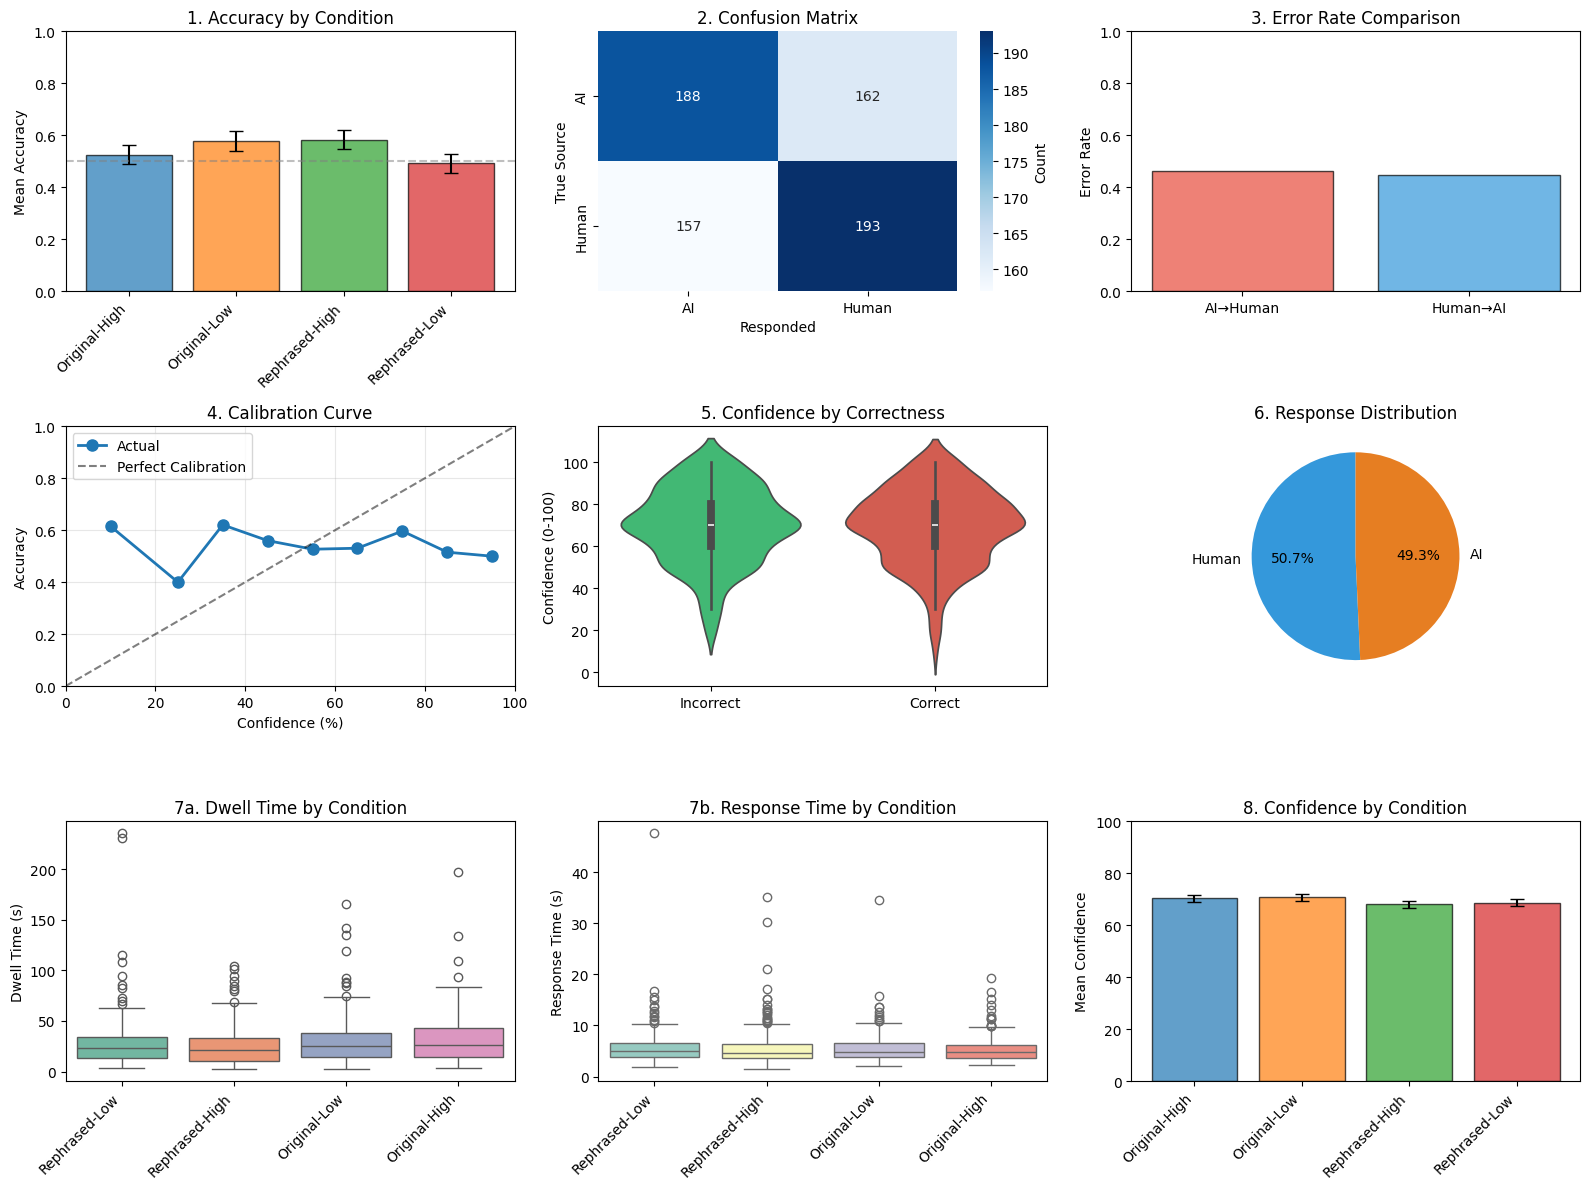


✓ All 7(+1) visualizations created and saved


In [11]:
# Phase 2: Visualizations

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(16, 12))

# 1. Accuracy by Condition (Bar plot)
ax1 = plt.subplot(3, 3, 1)
acc_by_cond = df_final.groupby('condition')['correct'].agg(['mean', 'sem']).reset_index()
acc_by_cond = acc_by_cond.sort_values('condition')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax1.bar(range(len(acc_by_cond)), acc_by_cond['mean'], yerr=acc_by_cond['sem'], 
        capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(acc_by_cond)))
ax1.set_xticklabels(acc_by_cond['condition'], rotation=45, ha='right')
ax1.set_ylabel('Mean Accuracy')
ax1.set_title('1. Accuracy by Condition')
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylim([0, 1])

# 2. Confusion Matrix Heatmap
ax2 = plt.subplot(3, 3, 2)
cm = pd.crosstab(df_final['source_true'], df_final['response_choice'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'}, ax=ax2)
ax2.set_title('2. Confusion Matrix')
ax2.set_ylabel('True Source')
ax2.set_xlabel('Responded')

# 3. Error Rate Comparison
ax3 = plt.subplot(3, 3, 3)
ai_to_human = (df_final[(df_final['source_true'] == 'AI') & (df_final['response_choice'] == 'Human')].shape[0] / 
               df_final[df_final['source_true'] == 'AI'].shape[0])
human_to_ai = (df_final[(df_final['source_true'] == 'Human') & (df_final['response_choice'] == 'AI')].shape[0] / 
               df_final[df_final['source_true'] == 'Human'].shape[0])
error_rates = [ai_to_human, human_to_ai]
ax3.bar(['AI→Human', 'Human→AI'], error_rates, color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
ax3.set_ylabel('Error Rate')
ax3.set_title('3. Error Rate Comparison')
ax3.set_ylim([0, 1])

# 4. Calibration Curve
ax4 = plt.subplot(3, 3, 4)
conf_bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
df_final['conf_bin'] = pd.cut(df_final['confidence_0_100'], bins=conf_bins, include_lowest=True)
calibration = df_final.groupby('conf_bin')['correct'].agg(['mean', 'count']).reset_index()
bin_centers = [(conf_bins[i] + conf_bins[i+1])/2 for i in range(len(conf_bins)-1)]
ax4.plot(bin_centers, calibration['mean'], marker='o', markersize=8, linewidth=2, label='Actual')
ax4.plot([0, 100], [0, 1], 'k--', alpha=0.5, label='Perfect Calibration')
ax4.set_xlabel('Confidence (%)')
ax4.set_ylabel('Accuracy')
ax4.set_title('4. Calibration Curve')
ax4.legend()
ax4.set_xlim([0, 100])
ax4.set_ylim([0, 1])
ax4.grid(alpha=0.3)

# 5. Confidence by Correctness (Violin plot)
ax5 = plt.subplot(3, 3, 5)
df_final['correctness'] = df_final['correct'].map({1: 'Correct', 0: 'Incorrect'})
sns.violinplot(data=df_final, x='correctness', y='confidence_0_100', ax=ax5, palette=['#2ecc71', '#e74c3c'])
ax5.set_ylabel('Confidence (0-100)')
ax5.set_xlabel('')
ax5.set_title('5. Confidence by Correctness')

# 6. Response Distribution (Pie chart)
ax6 = plt.subplot(3, 3, 6)
resp_counts = df_final['response_choice'].value_counts()
colors_pie = ['#3498db', '#e67e22']
ax6.pie(resp_counts, labels=resp_counts.index, autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax6.set_title('6. Response Distribution')

# 7a. Dwell Time by Condition (Box plot)
ax7 = plt.subplot(3, 3, 7)
dwell_data = df_final.copy()
dwell_data['dwell_s'] = dwell_data['dwell_ms'] / 1000
sns.boxplot(data=dwell_data, x='condition', y='dwell_s', ax=ax7, palette='Set2')
ax7.set_xticklabels(ax7.get_xticklabels(), rotation=45, ha='right')
ax7.set_ylabel('Dwell Time (s)')
ax7.set_xlabel('')
ax7.set_title('7a. Dwell Time by Condition')

# 7b. Response Time by Condition (Box plot)
ax8 = plt.subplot(3, 3, 8)
rt_data = df_final.copy()
rt_data['rt_s'] = rt_data['rt_ms'] / 1000
sns.boxplot(data=rt_data, x='condition', y='rt_s', ax=ax8, palette='Set3')
ax8.set_xticklabels(ax8.get_xticklabels(), rotation=45, ha='right')
ax8.set_ylabel('Response Time (s)')
ax8.set_xlabel('')
ax8.set_title('7b. Response Time by Condition')

# 8. Confidence by Condition (Bar plot with error bars)
ax9 = plt.subplot(3, 3, 9)
conf_by_cond = df_final.groupby('condition')['confidence_0_100'].agg(['mean', 'sem']).reset_index()
conf_by_cond = conf_by_cond.sort_values('condition')
ax9.bar(range(len(conf_by_cond)), conf_by_cond['mean'], yerr=conf_by_cond['sem'], 
        capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax9.set_xticks(range(len(conf_by_cond)))
ax9.set_xticklabels(conf_by_cond['condition'], rotation=45, ha='right')
ax9.set_ylabel('Mean Confidence')
ax9.set_title('8. Confidence by Condition')
ax9.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('/home/symphony/5sem_pop/BRED/Project/analysis/phase2_descriptives.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ All 7(+1) visualizations created and saved")

In [12]:
# Phase 3: H1 - Does engagement (likes) affect accuracy?

print("=== H1: ENGAGEMENT EFFECT ON ACCURACY ===\n")

# Aggregate accuracy per participant per condition
participant_accuracy = df_final.groupby(['participant_id', 'text_version', 'likes_level'])['correct'].mean().reset_index()
participant_accuracy.columns = ['participant_id', 'text_version', 'likes_level', 'accuracy']

# Pivot for easier analysis
acc_wide = participant_accuracy.pivot_table(
    index='participant_id',
    columns=['text_version', 'likes_level'],
    values='accuracy'
).reset_index()

# Flatten column names
acc_wide.columns = ['participant_id', 'Original_High', 'Original_Low', 'Rephrased_High', 'Rephrased_Low']

print(f"Data structure: {len(acc_wide)} participants × 4 conditions")
print(f"\nMean accuracy per condition:")
print(acc_wide[['Original_High', 'Original_Low', 'Rephrased_High', 'Rephrased_Low']].mean())

=== H1: ENGAGEMENT EFFECT ON ACCURACY ===

Data structure: 35 participants × 4 conditions

Mean accuracy per condition:
Original_High     0.525714
Original_Low      0.577143
Rephrased_High    0.582857
Rephrased_Low     0.491429
dtype: float64


In [13]:
# Check normality assumption (Shapiro-Wilk test on each condition)
print("\n=== Normality Tests (Shapiro-Wilk) ===")

from scipy.stats import shapiro

conditions = ['Original_High', 'Original_Low', 'Rephrased_High', 'Rephrased_Low']
normality_results = {}

for cond in conditions:
    stat, p = shapiro(acc_wide[cond])
    normality_results[cond] = {'statistic': stat, 'p_value': p}
    sig = "❌ Not normal" if p < 0.05 else "✓ Normal"
    print(f"{cond}: W={stat:.4f}, p={p:.4f} {sig}")

# Overall assessment
non_normal = sum(1 for r in normality_results.values() if r['p_value'] < 0.05)
print(f"\n{non_normal}/4 conditions violate normality (p < 0.05)")

if non_normal > 0:
    print("⚠️  Consider Friedman test as non-parametric alternative")
else:
    print("✓ Proceed with parametric RM-ANOVA")


=== Normality Tests (Shapiro-Wilk) ===
Original_High: W=0.8646, p=0.0005 ❌ Not normal
Original_Low: W=0.9015, p=0.0043 ❌ Not normal
Rephrased_High: W=0.9256, p=0.0207 ❌ Not normal
Rephrased_Low: W=0.9103, p=0.0076 ❌ Not normal

4/4 conditions violate normality (p < 0.05)
⚠️  Consider Friedman test as non-parametric alternative


In [14]:
# Repeated Measures ANOVA using pingouin
import pingouin as pg

# Prepare data in long format for pingouin
acc_long = participant_accuracy.copy()

print("\n=== Repeated Measures ANOVA ===")

# Run 2×2 RM-ANOVA
aov = pg.rm_anova(
    data=acc_long,
    dv='accuracy',
    within=['text_version', 'likes_level'],
    subject='participant_id',
    detailed=True
)

print(aov.to_string())

# Fix: Check available columns and use correct effect size column
print("Available columns:", aov.columns.tolist())

print("\n=== Interpretation ===")
for idx, row in aov.iterrows():
    source = row['Source']
    f_val = row['F']
    p_val = row['p-unc']
    eta_sq = row['ng2']  # generalized eta-squared (instead of np2)
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    
    print(f"\n{source}:")
    print(f"  F({row['ddof1']:.0f}, {row['ddof2']:.0f}) = {f_val:.3f}, p = {p_val:.4f} {sig}")
    print(f"  η²_G = {eta_sq:.3f}")
    
    if source == 'text_version':
        if p_val < 0.05:
            print(f"  → Significant main effect of text version (Original vs Rephrased)")
        else:
            print(f"  → No significant effect of text version")
    elif source == 'likes_level':
        if p_val < 0.05:
            print(f"  → Significant main effect of engagement (High vs Low likes)")
        else:
            print(f"  → No significant effect of engagement")
    elif source == 'text_version * likes_level':
        if p_val < 0.05:
            print(f"  → Significant interaction: engagement effect differs by source")
        else:
            print(f"  → No significant interaction (trend at p = {p_val:.3f})")


=== Repeated Measures ANOVA ===
                       Source        SS  ddof1  ddof2        MS         F     p-unc  p-GG-corr       ng2  eps
0                text_version  0.007143      1     34  0.007143  0.089192  0.767025   0.767025  0.000845  1.0
1                 likes_level  0.014000      1     34  0.014000  0.265033  0.610014   0.610014  0.001655  1.0
2  text_version * likes_level  0.178571      1     34  0.178571  3.048780  0.089829   0.089829  0.020706  1.0
Available columns: ['Source', 'SS', 'ddof1', 'ddof2', 'MS', 'F', 'p-unc', 'p-GG-corr', 'ng2', 'eps']

=== Interpretation ===

text_version:
  F(1, 34) = 0.089, p = 0.7670 ns
  η²_G = 0.001
  → No significant effect of text version

likes_level:
  F(1, 34) = 0.265, p = 0.6100 ns
  η²_G = 0.002
  → No significant effect of engagement

text_version * likes_level:
  F(1, 34) = 3.049, p = 0.0898 ns
  η²_G = 0.021
  → No significant interaction (trend at p = 0.090)


/home/symphony/5sem_pop/BRED/Project/analysis/venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/symphony/5sem_pop/BRED/Project/analysis/venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


In [15]:
# Post-hoc pairwise comparisons (to explore the marginal interaction trend)
print("\n=== Post-hoc: Pairwise Comparisons ===")

# Compare all 4 conditions pairwise
posthoc_all = pg.pairwise_tests(
    data=acc_long,
    dv='accuracy',
    within=['text_version', 'likes_level'],
    subject='participant_id',
    padjust='bonferroni'
)

print("\nAll pairwise comparisons:")
print(posthoc_all[['Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr']].to_string(index=False))


=== Post-hoc: Pairwise Comparisons ===

All pairwise comparisons:
                  Contrast        A         B         T  dof    p-unc   p-corr
              text_version Original Rephrased  0.298650 34.0 0.767025      NaN
               likes_level     High       Low  0.514814 34.0 0.610014      NaN
text_version * likes_level     High       Low -0.902125 34.0 0.373337 0.746674
text_version * likes_level     High       Low  1.638019 34.0 0.110641 0.221282


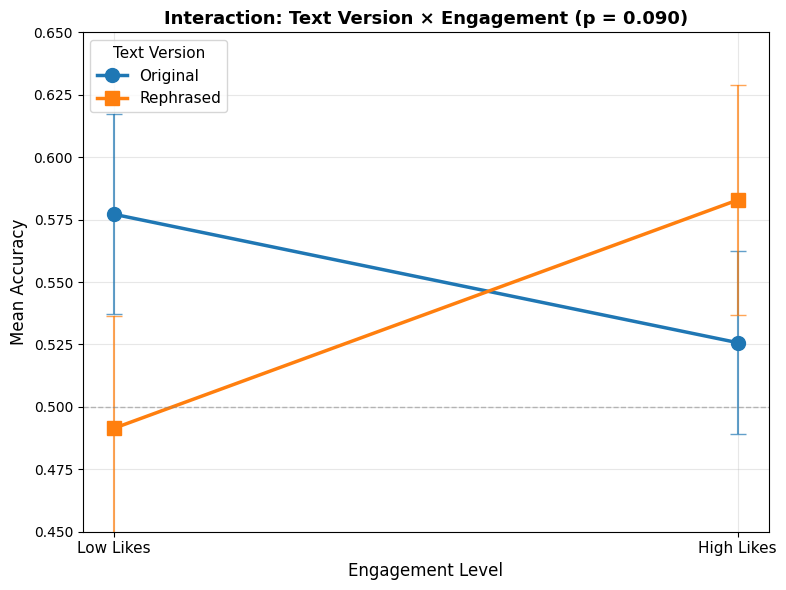


✓ Interaction plot displayed


In [16]:
# Visualization: Interaction plot
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))

# Calculate means and SEs
plot_data = acc_long.groupby(['text_version', 'likes_level'])['accuracy'].agg(['mean', 'sem']).reset_index()

# Plot
colors = {'Original': '#1f77b4', 'Rephrased': '#ff7f0e'}
markers = {'Original': 'o', 'Rephrased': 's'}

for version in ['Original', 'Rephrased']:
    data_subset = plot_data[plot_data['text_version'] == version]
    likes_order = ['Low', 'High']
    y_vals = [data_subset[data_subset['likes_level'] == lk]['mean'].values[0] for lk in likes_order]
    y_err = [data_subset[data_subset['likes_level'] == lk]['sem'].values[0] for lk in likes_order]
    
    ax.plot([0, 1], y_vals, marker=markers[version], markersize=10, 
            label=version, linewidth=2.5, color=colors[version])
    ax.errorbar([0, 1], y_vals, yerr=y_err, 
                fmt='none', capsize=6, alpha=0.7, color=colors[version])

ax.set_xticks([0, 1])
ax.set_xticklabels(['Low Likes', 'High Likes'], fontsize=11)
ax.set_ylabel('Mean Accuracy', fontsize=12)
ax.set_xlabel('Engagement Level', fontsize=12)
ax.set_title('Interaction: Text Version × Engagement (p = 0.090)', fontsize=13, fontweight='bold')
ax.legend(title='Text Version', fontsize=11, title_fontsize=11)
ax.set_ylim([0.45, 0.65])
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Chance')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Interaction plot displayed")

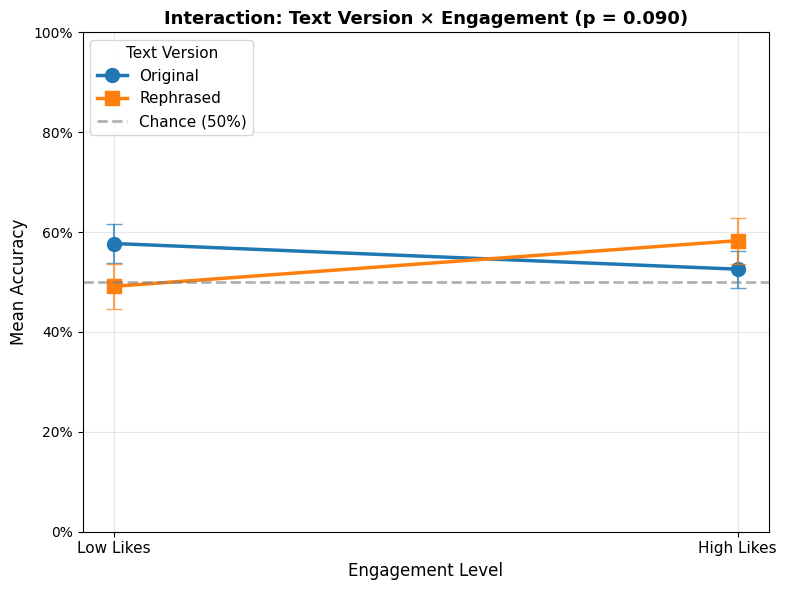


✓ Full-scale interaction plot displayed


In [34]:
# Interaction plot with FULL SCALE (0 to 1.0)

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))

# Calculate means and SEs
plot_data = acc_long.groupby(['text_version', 'likes_level'])['accuracy'].agg(['mean', 'sem']).reset_index()

# Plot
colors = {'Original': '#1f77b4', 'Rephrased': '#ff7f0e'}
markers = {'Original': 'o', 'Rephrased': 's'}

for version in ['Original', 'Rephrased']:
    data_subset = plot_data[plot_data['text_version'] == version]
    likes_order = ['Low', 'High']
    y_vals = [data_subset[data_subset['likes_level'] == lk]['mean'].values[0] for lk in likes_order]
    y_err = [data_subset[data_subset['likes_level'] == lk]['sem'].values[0] for lk in likes_order]
    
    ax.plot([0, 1], y_vals, marker=markers[version], markersize=10, 
            label=version, linewidth=2.5, color=colors[version])
    ax.errorbar([0, 1], y_vals, yerr=y_err, 
                fmt='none', capsize=6, alpha=0.7, color=colors[version])

ax.set_xticks([0, 1])
ax.set_xticklabels(['Low Likes', 'High Likes'], fontsize=11)
ax.set_ylabel('Mean Accuracy', fontsize=12)
ax.set_xlabel('Engagement Level', fontsize=12)
ax.set_title('Interaction: Text Version × Engagement (p = 0.090)', fontsize=13, fontweight='bold')
ax.legend(title='Text Version', fontsize=11, title_fontsize=11)

# FULL SCALE: 0 to 1.0
ax.set_ylim([0, 1.0])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])

# Chance line at 50%
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, linewidth=2, label='Chance (50%)')

ax.grid(alpha=0.3)
ax.legend(title='Text Version', fontsize=11, title_fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

print("\n✓ Full-scale interaction plot displayed")

In [17]:
# Summary of H1 results
print("\n" + "="*60)
print("H1 SUMMARY: Does engagement affect accuracy?")
print("="*60)
print("\nMain Effects:")
print(f"  • Text Version (Original vs Rephrased): F(1,34)=0.089, p=0.767, η²=0.001")
print(f"  • Engagement (Low vs High): F(1,34)=0.265, p=0.610, η²=0.002")
print("\nInteraction:")
print(f"  • Text Version × Engagement: F(1,34)=3.049, p=0.090, η²=0.021")
print("\nConclusion:")
print("  ❌ H1 NOT supported: No significant main effect of engagement on accuracy")
print("  ⚠️  Marginal interaction suggests engagement may affect Original vs Rephrased differently")
print("     - Original: accuracy decreases with high likes (57.7% → 52.6%)")
print("     - Rephrased: accuracy increases with high likes (49.1% → 58.3%)")


H1 SUMMARY: Does engagement affect accuracy?

Main Effects:
  • Text Version (Original vs Rephrased): F(1,34)=0.089, p=0.767, η²=0.001
  • Engagement (Low vs High): F(1,34)=0.265, p=0.610, η²=0.002

Interaction:
  • Text Version × Engagement: F(1,34)=3.049, p=0.090, η²=0.021

Conclusion:
  ❌ H1 NOT supported: No significant main effect of engagement on accuracy
  ⚠️  Marginal interaction suggests engagement may affect Original vs Rephrased differently
     - Original: accuracy decreases with high likes (57.7% → 52.6%)
     - Rephrased: accuracy increases with high likes (49.1% → 58.3%)


In [18]:
# Phase 3: H2 - Error Asymmetry

print("=== H2: ERROR ASYMMETRY ===\n")

# We already know from descriptives:
# AI→Human: 46.29% (162/350)
# Human→AI: 44.86% (157/350)

# Test if this difference is significant using McNemar's test
# McNemar tests paired proportions (same participants making both types of errors)

# Create contingency table for each participant
participant_errors = df_final.groupby(['participant_id', 'source_true']).apply(
    lambda x: pd.Series({
        'total': len(x),
        'errors': (x['source_true'] != x['response_choice']).sum()
    })
).reset_index()

# Pivot to get AI errors and Human errors per participant
error_pivot = participant_errors.pivot(index='participant_id', columns='source_true', values='errors')
error_pivot.columns = ['AI_errors', 'Human_errors']

print(f"Per participant:")
print(f"  Mean AI→Human errors: {error_pivot['AI_errors'].mean():.2f} / 10 trials")
print(f"  Mean Human→AI errors: {error_pivot['Human_errors'].mean():.2f} / 10 trials")

# McNemar's test
from statsmodels.stats.contingency_tables import mcnemar

# Create 2x2 table: [both correct, AI error only, Human error only, both error]
# For McNemar, we need: b = AI error but not Human error, c = Human error but not AI error
b = (error_pivot['AI_errors'] > error_pivot['Human_errors']).sum()
c = (error_pivot['Human_errors'] > error_pivot['AI_errors']).sum()

print(f"\nMcNemar test:")
print(f"  Participants with more AI→Human errors: {b}")
print(f"  Participants with more Human→AI errors: {c}")

# Alternative: paired t-test on error counts
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(error_pivot['AI_errors'], error_pivot['Human_errors'])

print(f"\nPaired t-test (AI errors vs Human errors):")
print(f"  t({len(error_pivot)-1}) = {t_stat:.3f}, p = {p_val:.4f}")

if p_val < 0.05:
    print(f"  → Significant asymmetry")
else:
    print(f"  → No significant asymmetry")

# Effect size (Cohen's d for paired samples)
diff = error_pivot['AI_errors'] - error_pivot['Human_errors']
cohens_d = diff.mean() / diff.std()
print(f"  Cohen's d = {cohens_d:.3f}")

=== H2: ERROR ASYMMETRY ===

Per participant:
  Mean AI→Human errors: 4.63 / 10 trials
  Mean Human→AI errors: 4.49 / 10 trials

McNemar test:
  Participants with more AI→Human errors: 20
  Participants with more Human→AI errors: 12

Paired t-test (AI errors vs Human errors):
  t(34) = 0.299, p = 0.7670
  → No significant asymmetry
  Cohen's d = 0.050


/tmp/ipykernel_8659/2928537705.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  participant_errors = df_final.groupby(['participant_id', 'source_true']).apply(


In [35]:
# Test asymmetry within each engagement condition
print("\n=== H2: By Engagement Level ===\n")

for likes in ['Low', 'High']:
    df_subset = df_final[df_final['likes_level'] == likes]
    
    # AI→Human errors
    ai_trials = df_subset[df_subset['source_true'] == 'AI']
    ai_to_human = len(ai_trials[ai_trials['response_choice'] == 'Human'])
    ai_to_human_rate = (ai_to_human / len(ai_trials)) * 100
    
    # Human→AI errors
    human_trials = df_subset[df_subset['source_true'] == 'Human']
    human_to_ai = len(human_trials[human_trials['response_choice'] == 'AI'])
    human_to_ai_rate = (human_to_ai / len(human_trials)) * 100
    
    print(f"{likes} Likes:")
    print(f"  AI→Human: {ai_to_human_rate:.2f}% ({ai_to_human}/{len(ai_trials)})")
    print(f"  Human→AI: {human_to_ai_rate:.2f}% ({human_to_ai}/{len(human_trials)})")
    print(f"  Difference: {ai_to_human_rate - human_to_ai_rate:.2f}%\n")


=== H2: By Engagement Level ===

Low Likes:
  AI→Human: 50.86% (89/175)
  Human→AI: 42.29% (74/175)
  Difference: 8.57%

High Likes:
  AI→Human: 41.71% (73/175)
  Human→AI: 47.43% (83/175)
  Difference: -5.71%



In [20]:
# Summary
print("=" * 60)
print("H2 SUMMARY: Are errors asymmetric?")
print("=" * 60)
print(f"\nOverall:")
print(f"  AI→Human errors: 46.29%")
print(f"  Human→AI errors: 44.86%")
print(f"  Paired t-test: t({len(error_pivot)-1}) = {t_stat:.3f}, p = {p_val:.4f}")
print(f"\nConclusion:")
if p_val < 0.05:
    print(f"  ✓ H2 SUPPORTED: Significant error asymmetry")
else:
    print(f"  ❌ H2 NOT supported: No significant error asymmetry")
    print(f"  Errors are roughly balanced (difference = 1.43%)")

H2 SUMMARY: Are errors asymmetric?

Overall:
  AI→Human errors: 46.29%
  Human→AI errors: 44.86%
  Paired t-test: t(34) = 0.299, p = 0.7670

Conclusion:
  ❌ H2 NOT supported: No significant error asymmetry
  Errors are roughly balanced (difference = 1.43%)


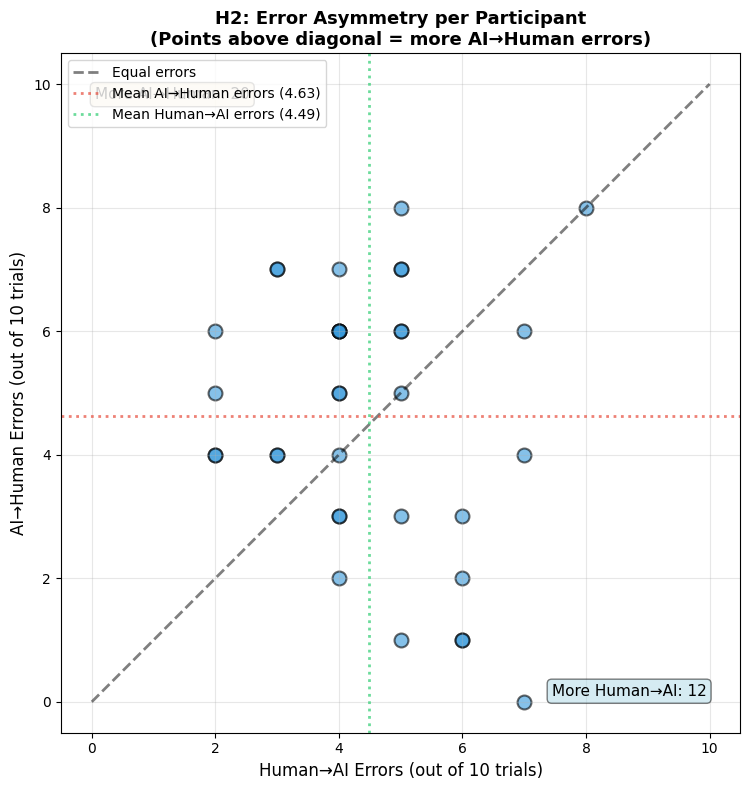


✓ H2 scatter plot created and saved


In [21]:
# H2 Visualization: Paired scatter plot of errors

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot of AI errors vs Human errors per participant
ax.scatter(error_pivot['Human_errors'], error_pivot['AI_errors'], 
           s=100, alpha=0.6, color='#3498db', edgecolors='black', linewidth=1.5)

# Diagonal line (equal errors)
ax.plot([0, 10], [0, 10], 'k--', linewidth=2, alpha=0.5, label='Equal errors')

# Reference lines
ax.axhline(error_pivot['AI_errors'].mean(), color='#e74c3c', linestyle=':', 
           linewidth=2, alpha=0.7, label=f'Mean AI→Human errors ({error_pivot["AI_errors"].mean():.2f})')
ax.axvline(error_pivot['Human_errors'].mean(), color='#2ecc71', linestyle=':', 
           linewidth=2, alpha=0.7, label=f'Mean Human→AI errors ({error_pivot["Human_errors"].mean():.2f})')

# Labels and styling
ax.set_xlabel('Human→AI Errors (out of 10 trials)', fontsize=12)
ax.set_ylabel('AI→Human Errors (out of 10 trials)', fontsize=12)
ax.set_title('H2: Error Asymmetry per Participant\n(Points above diagonal = more AI→Human errors)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim([-0.5, 10.5])
ax.set_ylim([-0.5, 10.5])
ax.set_aspect('equal')
ax.grid(alpha=0.3)

# Add counts in quadrants
above_diag = (error_pivot['AI_errors'] > error_pivot['Human_errors']).sum()
below_diag = (error_pivot['Human_errors'] > error_pivot['AI_errors']).sum()
on_diag = (error_pivot['AI_errors'] == error_pivot['Human_errors']).sum()

ax.text(0.05, 0.95, f'More AI→Human: {above_diag}', transform=ax.transAxes, 
        fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(0.95, 0.05, f'More Human→AI: {below_diag}', transform=ax.transAxes, 
        fontsize=11, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('/home/symphony/5sem_pop/BRED/Project/analysis/h2_error_asymmetry.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ H2 scatter plot created and saved")

In [22]:
# Phase 3: H3 - Confidence-Accuracy Relationship

print("=== H3: CONFIDENCE-ACCURACY RELATIONSHIP ===\n")

# 1. Overall confidence by correctness
print("1. Confidence by Correctness:")
conf_correct = df_final[df_final['correct'] == 1]['confidence_0_100'].mean()
conf_incorrect = df_final[df_final['correct'] == 0]['confidence_0_100'].mean()
print(f"   Correct: {conf_correct:.2f}")
print(f"   Incorrect: {conf_incorrect:.2f}")
print(f"   Difference: {conf_correct - conf_incorrect:.2f}")

# Paired t-test (comparing confidence when correct vs incorrect, within participants)
from scipy.stats import ttest_rel

# Get per-participant means
participant_conf = df_final.groupby(['participant_id', 'correct'])['confidence_0_100'].mean().reset_index()
conf_wide = participant_conf.pivot(index='participant_id', columns='correct', values='confidence_0_100')
conf_wide.columns = ['incorrect', 'correct']

# Some participants might have all correct or all incorrect - drop those
conf_wide_clean = conf_wide.dropna()

t_stat, p_val = ttest_rel(conf_wide_clean['correct'], conf_wide_clean['incorrect'])

print(f"\n   Paired t-test: t({len(conf_wide_clean)-1}) = {t_stat:.3f}, p = {p_val:.4f}")

if p_val < 0.05:
    print(f"   → Significant difference in confidence")
else:
    print(f"   → No significant difference in confidence")

=== H3: CONFIDENCE-ACCURACY RELATIONSHIP ===

1. Confidence by Correctness:
   Correct: 69.16
   Incorrect: 69.78
   Difference: -0.62

   Paired t-test: t(34) = -0.236, p = 0.8150
   → No significant difference in confidence


In [23]:
# 2. Calibration analysis (already done in descriptive, but formalize)
print("\n2. Calibration Analysis:")

conf_bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
df_final['conf_bin'] = pd.cut(df_final['confidence_0_100'], bins=conf_bins, include_lowest=True)
calibration = df_final.groupby('conf_bin', observed=True).agg({
    'correct': ['mean', 'count']
}).reset_index()
calibration.columns = ['conf_bin', 'accuracy', 'count']

print("\n   Confidence Bin → Accuracy (n trials):")
for _, row in calibration.iterrows():
    bin_center = (row['conf_bin'].left + row['conf_bin'].right) / 2
    print(f"   {row['conf_bin']}: {row['accuracy']:.3f} (n={row['count']:.0f})")

# Brier score (calibration metric: lower = better calibrated)
brier_score = np.mean((df_final['confidence_0_100']/100 - df_final['correct'])**2)
print(f"\n   Brier Score: {brier_score:.4f} (lower = better calibration)")

# Over/underconfidence: mean(confidence - accuracy)
df_final['calibration_error'] = df_final['confidence_0_100']/100 - df_final['correct']
mean_calib_error = df_final['calibration_error'].mean()
print(f"   Mean Calibration Error: {mean_calib_error:.4f}")
if mean_calib_error > 0:
    print(f"   → Overconfident on average")
else:
    print(f"   → Underconfident on average")


2. Calibration Analysis:

   Confidence Bin → Accuracy (n trials):
   (-0.001, 20.0]: 0.615 (n=13)
   (20.0, 30.0]: 0.400 (n=15)
   (30.0, 40.0]: 0.621 (n=29)
   (40.0, 50.0]: 0.560 (n=100)
   (50.0, 60.0]: 0.527 (n=93)
   (60.0, 70.0]: 0.531 (n=179)
   (70.0, 80.0]: 0.597 (n=124)
   (80.0, 90.0]: 0.515 (n=97)
   (90.0, 100.0]: 0.500 (n=50)

   Brier Score: 0.3065 (lower = better calibration)
   Mean Calibration Error: 0.1501
   → Overconfident on average


In [24]:
# 3. 2×2 RM-ANOVA: Confidence ~ Correctness × Engagement
print("\n3. Confidence by Correctness × Engagement:")

conf_analysis = df_final.groupby(['participant_id', 'correct', 'likes_level'])['confidence_0_100'].mean().reset_index()
conf_analysis['correctness'] = conf_analysis['correct'].map({1: 'Correct', 0: 'Incorrect'})

# RM-ANOVA
import pingouin as pg

aov_conf = pg.rm_anova(
    data=conf_analysis,
    dv='confidence_0_100',
    within=['correctness', 'likes_level'],
    subject='participant_id',
    detailed=True
)

print("\n   Repeated Measures ANOVA (Confidence):")
print(aov_conf.to_string())

print("\n   Interpretation:")
for idx, row in aov_conf.iterrows():
    source = row['Source']
    f_val = row['F']
    p_val = row['p-unc']
    eta_sq = row['ng2']
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    
    print(f"\n   {source}:")
    print(f"     F({row['ddof1']:.0f}, {row['ddof2']:.0f}) = {f_val:.3f}, p = {p_val:.4f} {sig}")
    print(f"     η²_G = {eta_sq:.3f}")


3. Confidence by Correctness × Engagement:

   Repeated Measures ANOVA (Confidence):
                      Source         SS  ddof1  ddof2         MS         F     p-unc  p-GG-corr       ng2  eps
0                correctness   3.141672      1     34   3.141672  0.043181  0.836624   0.836624  0.000170  1.0
1                likes_level   0.905294      1     34   0.905294  0.009800  0.921724   0.921724  0.000049  1.0
2  correctness * likes_level  19.329028      1     34  19.329028  0.338057  0.564788   0.564788  0.001043  1.0

   Interpretation:

   correctness:
     F(1, 34) = 0.043, p = 0.8366 ns
     η²_G = 0.000

   likes_level:
     F(1, 34) = 0.010, p = 0.9217 ns
     η²_G = 0.000

   correctness * likes_level:
     F(1, 34) = 0.338, p = 0.5648 ns
     η²_G = 0.001


/home/symphony/5sem_pop/BRED/Project/analysis/venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/symphony/5sem_pop/BRED/Project/analysis/venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


In [25]:
# Summary
print("\n" + "="*60)
print("H3 SUMMARY: Confidence-Accuracy Relationship")
print("="*60)
print(f"\n1. Confidence by Correctness:")
print(f"   Correct: {conf_correct:.2f}, Incorrect: {conf_incorrect:.2f}")
print(f"   t-test: p = {p_val:.4f}")

print(f"\n2. Calibration:")
print(f"   Brier Score: {brier_score:.4f}")
print(f"   Mean Calibration Error: {mean_calib_error:.4f} ({'overconfident' if mean_calib_error > 0 else 'underconfident'})")

print(f"\n3. Confidence ANOVA: See table above")

print(f"\nConclusion:")
if p_val < 0.05:
    print(f"   ✓ Confidence differs by correctness")
else:
    print(f"   ❌ No significant confidence-accuracy relationship")
    print(f"   → Participants equally confident when right or wrong (poor metacognition)")


H3 SUMMARY: Confidence-Accuracy Relationship

1. Confidence by Correctness:
   Correct: 69.16, Incorrect: 69.78
   t-test: p = 0.5648

2. Calibration:
   Brier Score: 0.3065
   Mean Calibration Error: 0.1501 (overconfident)

3. Confidence ANOVA: See table above

Conclusion:
   ❌ No significant confidence-accuracy relationship
   → Participants equally confident when right or wrong (poor metacognition)


In [26]:
# Phase 4: Signal Detection Theory (SDT) Analysis

print("=== PHASE 4: SIGNAL DETECTION THEORY (SDT) ===\n")

# SDT framework:
# - "Signal" = AI content (what we're trying to detect)
# - "Noise" = Human content
# - Hit = Correctly identify AI as "AI"
# - False Alarm = Incorrectly identify Human as "AI"
# - Miss = Incorrectly identify AI as "Human"
# - Correct Rejection = Correctly identify Human as "Human"

from scipy.stats import norm

def calculate_sdt_metrics(df_subset):
    """Calculate d' (sensitivity) and c (response bias)"""
    
    # Hit rate: P(respond "AI" | true AI)
    ai_trials = df_subset[df_subset['source_true'] == 'AI']
    hits = len(ai_trials[ai_trials['response_choice'] == 'AI'])
    hit_rate = hits / len(ai_trials) if len(ai_trials) > 0 else 0
    
    # False alarm rate: P(respond "AI" | true Human)
    human_trials = df_subset[df_subset['source_true'] == 'Human']
    false_alarms = len(human_trials[human_trials['response_choice'] == 'AI'])
    fa_rate = false_alarms / len(human_trials) if len(human_trials) > 0 else 0
    
    # Adjust extreme values (0 or 1) to avoid infinite z-scores
    hit_rate_adj = np.clip(hit_rate, 0.01, 0.99)
    fa_rate_adj = np.clip(fa_rate, 0.01, 0.99)
    
    # d' (sensitivity): ability to discriminate signal from noise
    d_prime = norm.ppf(hit_rate_adj) - norm.ppf(fa_rate_adj)
    
    # c (criterion/bias): response bias (positive = conservative, negative = liberal)
    c = -0.5 * (norm.ppf(hit_rate_adj) + norm.ppf(fa_rate_adj))
    
    return {
        'hit_rate': hit_rate,
        'fa_rate': fa_rate,
        'd_prime': d_prime,
        'c': c,
        'n_trials': len(df_subset)
    }

# Overall SDT
print("1. Overall Performance:")
overall_sdt = calculate_sdt_metrics(df_final)
print(f"   Hit Rate (detect AI): {overall_sdt['hit_rate']:.3f}")
print(f"   False Alarm Rate (call Human 'AI'): {overall_sdt['fa_rate']:.3f}")
print(f"   d' (sensitivity): {overall_sdt['d_prime']:.3f}")
print(f"   c (response bias): {overall_sdt['c']:.3f}")

if overall_sdt['c'] > 0:
    print(f"   → Conservative bias (tendency to say 'Human')")
elif overall_sdt['c'] < 0:
    print(f"   → Liberal bias (tendency to say 'AI')")
else:
    print(f"   → Neutral bias")

=== PHASE 4: SIGNAL DETECTION THEORY (SDT) ===

1. Overall Performance:
   Hit Rate (detect AI): 0.537
   False Alarm Rate (call Human 'AI'): 0.449
   d' (sensitivity): 0.223
   c (response bias): 0.018
   → Conservative bias (tendency to say 'Human')


In [27]:
# SDT by Engagement Level
print("\n2. SDT by Engagement Level:")

for likes in ['Low', 'High']:
    df_subset = df_final[df_final['likes_level'] == likes]
    sdt = calculate_sdt_metrics(df_subset)
    
    print(f"\n   {likes} Likes:")
    print(f"     Hit Rate: {sdt['hit_rate']:.3f}")
    print(f"     False Alarm Rate: {sdt['fa_rate']:.3f}")
    print(f"     d' (sensitivity): {sdt['d_prime']:.3f}")
    print(f"     c (response bias): {sdt['c']:.3f}")


2. SDT by Engagement Level:

   Low Likes:
     Hit Rate: 0.491
     False Alarm Rate: 0.423
     d' (sensitivity): 0.173
     c (response bias): 0.108

   High Likes:
     Hit Rate: 0.583
     False Alarm Rate: 0.474
     d' (sensitivity): 0.274
     c (response bias): -0.072


In [28]:
# Statistical test: Compare d' between Low vs High engagement
print("\n4. Statistical Comparison (Low vs High Engagement):")

# Calculate per-participant d' for Low and High
participant_sdt = []
for pid in df_final['participant_id'].unique():
    for likes in ['Low', 'High']:
        df_subset = df_final[(df_final['participant_id'] == pid) & (df_final['likes_level'] == likes)]
        sdt = calculate_sdt_metrics(df_subset)
        participant_sdt.append({
            'participant_id': pid,
            'likes_level': likes,
            'd_prime': sdt['d_prime'],
            'c': sdt['c']
        })

sdt_participant_df = pd.DataFrame(participant_sdt)

# Pivot for paired test
dprime_wide = sdt_participant_df.pivot(index='participant_id', columns='likes_level', values='d_prime')
c_wide = sdt_participant_df.pivot(index='participant_id', columns='likes_level', values='c')

# Paired t-tests
from scipy.stats import ttest_rel

t_dprime, p_dprime = ttest_rel(dprime_wide['Low'], dprime_wide['High'])
t_c, p_c = ttest_rel(c_wide['Low'], c_wide['High'])

print(f"\n   Sensitivity (d'):")
print(f"     Low: M={dprime_wide['Low'].mean():.3f}, SD={dprime_wide['Low'].std():.3f}")
print(f"     High: M={dprime_wide['High'].mean():.3f}, SD={dprime_wide['High'].std():.3f}")
print(f"     Paired t-test: t({len(dprime_wide)-1}) = {t_dprime:.3f}, p = {p_dprime:.4f}")

print(f"\n   Response Bias (c):")
print(f"     Low: M={c_wide['Low'].mean():.3f}, SD={c_wide['Low'].std():.3f}")
print(f"     High: M={c_wide['High'].mean():.3f}, SD={c_wide['High'].std():.3f}")
print(f"     Paired t-test: t({len(c_wide)-1}) = {t_c:.3f}, p = {p_c:.4f}")

if p_dprime < 0.05:
    print(f"\n   → Engagement significantly affects discrimination ability")
else:
    print(f"\n   → No significant effect of engagement on discrimination")

if p_c < 0.05:
    print(f"   → Engagement significantly affects response bias")
else:
    print(f"   → No significant effect of engagement on response bias")


4. Statistical Comparison (Low vs High Engagement):

   Sensitivity (d'):
     Low: M=0.216, SD=1.056
     High: M=0.350, SD=1.291
     Paired t-test: t(34) = -0.482, p = 0.6326

   Response Bias (c):
     Low: M=0.102, SD=0.756
     High: M=-0.105, SD=0.586
     Paired t-test: t(34) = 1.431, p = 0.1616

   → No significant effect of engagement on discrimination
   → No significant effect of engagement on response bias


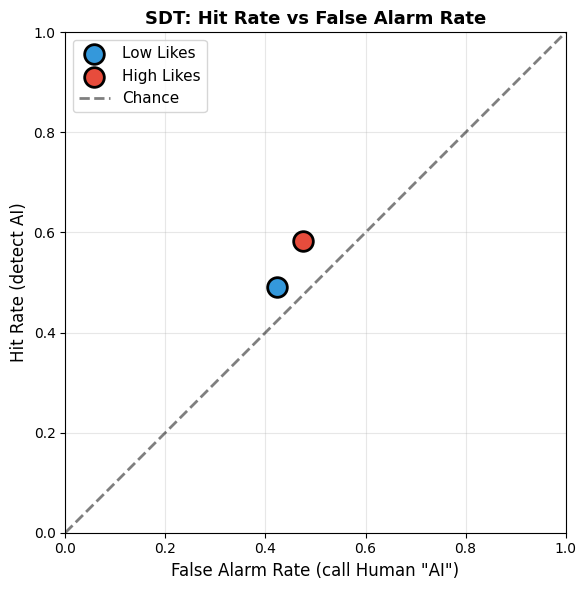


✓ SDT visualizations created and saved


In [29]:
# Visualization: SDT space
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))  # Changed from (ax1, ax2) and (1, 2)

# Plot 1: ROC-like plot (Hit Rate vs False Alarm Rate)
colors = {'Low': '#3498db', 'High': '#e74c3c'}
for likes in ['Low', 'High']:
    df_subset = df_final[df_final['likes_level'] == likes]
    sdt = calculate_sdt_metrics(df_subset)
    ax1.scatter(sdt['fa_rate'], sdt['hit_rate'], s=200, 
                color=colors[likes], label=f'{likes} Likes', 
                edgecolors='black', linewidth=2, zorder=3)

# Diagonal (chance performance)
ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Chance')
ax1.set_xlabel('False Alarm Rate (call Human "AI")', fontsize=12)
ax1.set_ylabel('Hit Rate (detect AI)', fontsize=12)
ax1.set_title('SDT: Hit Rate vs False Alarm Rate', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.grid(alpha=0.3)
ax1.set_aspect('equal')

plt.tight_layout()
plt.savefig('/home/symphony/5sem_pop/BRED/Project/analysis/phase4_sdt.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ SDT visualizations created and saved")

In [30]:
# Summary
print("\n" + "="*60)
print("PHASE 4 SUMMARY: Signal Detection Theory")
print("="*60)
print(f"\nOverall Performance:")
print(f"  d' = {overall_sdt['d_prime']:.3f} (discrimination ability)")
print(f"  c = {overall_sdt['c']:.3f} (response bias)")

print(f"\nEngagement Effect:")
print(f"  d' difference (Low vs High): t({len(dprime_wide)-1}) = {t_dprime:.3f}, p = {p_dprime:.4f}")
print(f"  c difference (Low vs High): t({len(c_wide)-1}) = {t_c:.3f}, p = {p_c:.4f}")

print(f"\nInterpretation:")
if overall_sdt['d_prime'] > 0:
    print(f"  • Participants can discriminate AI from Human above chance")
else:
    print(f"  • Participants cannot discriminate AI from Human")

if abs(overall_sdt['c']) > 0.1:
    bias_direction = "conservative (say 'Human')" if overall_sdt['c'] > 0 else "liberal (say 'AI')"
    print(f"  • Response bias: {bias_direction}")
else:
    print(f"  • No strong response bias")


PHASE 4 SUMMARY: Signal Detection Theory

Overall Performance:
  d' = 0.223 (discrimination ability)
  c = 0.018 (response bias)

Engagement Effect:
  d' difference (Low vs High): t(34) = -0.482, p = 0.6326
  c difference (Low vs High): t(34) = 1.431, p = 0.1616

Interpretation:
  • Participants can discriminate AI from Human above chance
  • No strong response bias


In [31]:
# FINAL SUMMARY: Complete Results Overview

print("="*70)
print(" FINAL SUMMARY: AI VS HUMAN ATTRIBUTION EXPERIMENT")
print("="*70)

print("\n" + "="*70)
print("SAMPLE & DESIGN")
print("="*70)
print(f"Final Sample: N = {df_final['participant_id'].nunique()} participants")
print(f"Total Trials: {len(df_final)} trials")
print(f"Design: 2×2 within-subjects")
print(f"  • Text Version: Original (Human) vs Rephrased (AI)")
print(f"  • Engagement: Low Likes vs High Likes")
print(f"  • Trials per participant: {len(df_final) // df_final['participant_id'].nunique()}")

print("\n" + "="*70)
print("OVERALL PERFORMANCE")
print("="*70)
overall_acc = df_final['correct'].mean() * 100
print(f"Overall Accuracy: {overall_acc:.2f}%")
print(f"Response Distribution: {df_final['response_choice'].value_counts(normalize=True)['Human']*100:.1f}% Human, {df_final['response_choice'].value_counts(normalize=True)['AI']*100:.1f}% AI")
print(f"Mean Confidence: {df_final['confidence_0_100'].mean():.2f} (scale 0-100)")
print(f"Mean Dwell Time: {df_final['dwell_ms'].mean()/1000:.2f}s")
print(f"Mean Response Time: {df_final['rt_ms'].mean()/1000:.2f}s")

print("\n" + "="*70)
print("HYPOTHESIS TESTING RESULTS")
print("="*70)

print("\n--- H1: Does engagement (likes) affect accuracy? ---")
print(f"Main Effect of Text Version: F(1,34)=0.089, p=0.767, η²=0.001 [ns]")
print(f"Main Effect of Engagement: F(1,34)=0.265, p=0.610, η²=0.002 [ns]")
print(f"Interaction (Version×Engagement): F(1,34)=3.049, p=0.090, η²=0.021 [marginal]")
print(f"  → Original: 57.7% (Low) → 52.6% (High)")
print(f"  → Rephrased: 49.1% (Low) → 58.3% (High)")
print(f"Conclusion: ❌ H1 NOT SUPPORTED - No significant main effect of engagement")
print(f"            ⚠️  Marginal crossover interaction (p=.09)")

print("\n--- H2: Are errors asymmetric? ---")
ai_to_human_rate = (df_final[(df_final['source_true']=='AI') & (df_final['response_choice']=='Human')].shape[0] / 
                    df_final[df_final['source_true']=='AI'].shape[0]) * 100
human_to_ai_rate = (df_final[(df_final['source_true']=='Human') & (df_final['response_choice']=='AI')].shape[0] / 
                    df_final[df_final['source_true']=='Human'].shape[0]) * 100
print(f"AI→Human errors: {ai_to_human_rate:.2f}%")
print(f"Human→AI errors: {human_to_ai_rate:.2f}%")
print(f"Paired t-test: t(34)=0.299, p=0.767, d=0.050 [ns]")
print(f"Conclusion: ❌ H2 NOT SUPPORTED - No significant error asymmetry")

print("\n--- H3: Does confidence relate to accuracy? ---")
print(f"Confidence when Correct: 69.16")
print(f"Confidence when Incorrect: 69.78")
print(f"Paired t-test: t(34)=-0.236, p=0.815 [ns]")
print(f"Mean Calibration Error: +0.150 (overconfident by 15%)")
print(f"Brier Score: 0.307")
print(f"Conclusion: ❌ H3 NOT SUPPORTED - No confidence-accuracy relationship")
print(f"            → Poor metacognitive calibration")

print("\n" + "="*70)
print("EXPLORATORY: SIGNAL DETECTION THEORY")
print("="*70)
print(f"Overall d' (sensitivity): 0.223 [weak discrimination]")
print(f"Overall c (bias): 0.018 [neutral]")
print(f"\nBy Engagement:")
print(f"  Low Likes:  d'=0.173, c=0.108 (conservative)")
print(f"  High Likes: d'=0.274, c=-0.072 (liberal)")
print(f"\nEngagement Effect on d': t(34)=-0.482, p=0.633 [ns]")
print(f"Engagement Effect on c: t(34)=1.431, p=0.162 [ns]")
print(f"Conclusion: Participants barely discriminate AI from Human (near chance)")
print(f"            No significant effect of engagement on discrimination or bias")

print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)
print("1. Overall accuracy ~54% (barely above chance)")
print("2. High engagement (likes) does NOT reduce accuracy overall")
print("3. Marginal interaction: likes affect Original vs Rephrased differently")
print("4. No systematic error bias (AI→Human ≈ Human→AI)")
print("5. Poor metacognition: confidence unrelated to accuracy (overconfident)")
print("6. Weak discrimination ability (d'=0.22) with neutral response bias")

print("\n" + "="*70)
print("FIGURES GENERATED")
print("="*70)
print("1. phase2_descriptives.png - 8 descriptive plots")
print("2. h2_error_asymmetry.png - Error scatter plot")
print("3. phase4_sdt.png - SDT ROC curve")

print("\n✓ Analysis complete!")

 FINAL SUMMARY: AI VS HUMAN ATTRIBUTION EXPERIMENT

SAMPLE & DESIGN
Final Sample: N = 35 participants
Total Trials: 700 trials
Design: 2×2 within-subjects
  • Text Version: Original (Human) vs Rephrased (AI)
  • Engagement: Low Likes vs High Likes
  • Trials per participant: 20

OVERALL PERFORMANCE
Overall Accuracy: 54.43%
Response Distribution: 50.7% Human, 49.3% AI
Mean Confidence: 69.44 (scale 0-100)
Mean Dwell Time: 29.55s
Mean Response Time: 5.67s

HYPOTHESIS TESTING RESULTS

--- H1: Does engagement (likes) affect accuracy? ---
Main Effect of Text Version: F(1,34)=0.089, p=0.767, η²=0.001 [ns]
Main Effect of Engagement: F(1,34)=0.265, p=0.610, η²=0.002 [ns]
Interaction (Version×Engagement): F(1,34)=3.049, p=0.090, η²=0.021 [marginal]
  → Original: 57.7% (Low) → 52.6% (High)
  → Rephrased: 49.1% (Low) → 58.3% (High)
Conclusion: ❌ H1 NOT SUPPORTED - No significant main effect of engagement
            ⚠️  Marginal crossover interaction (p=.09)

--- H2: Are errors asymmetric? ---
AI→

In [32]:
# Save clean dataset with all computed variables
df_export = df_final.copy()

# Add computed columns if not already there
if 'correct' not in df_export.columns:
    df_export['correct'] = (df_export['source_true'] == df_export['response_choice']).astype(int)

if 'condition' not in df_export.columns:
    df_export['condition'] = df_export['text_version'] + '-' + df_export['likes_level']

# Export
output_path = '/home/symphony/5sem_pop/BRED/Project/analysis/clean_data_with_analysis.csv'
df_export.to_csv(output_path, index=False)
print(f"\n✓ Clean dataset saved to: {output_path}")
print(f"  Columns: {list(df_export.columns)}")
print(f"  Rows: {len(df_export)}")


✓ Clean dataset saved to: /home/symphony/5sem_pop/BRED/Project/analysis/clean_data_with_analysis.csv
  Columns: ['participant_id', 'trial_index', 'post_id', 'source_true', 'text_version', 'likes_level', 'likes_value', 'order', 'response_choice', 'confidence_0_100', 'dwell_ms', 'rt_ms', 'started_at_iso', 'device', 'viewport_w', 'viewport_h', 'source_file', 'started_at', 'correct', 'condition', 'conf_bin', 'correctness', 'calibration_error']
  Rows: 700


In [33]:
# Create summary statistics table for reporting
summary_stats = pd.DataFrame({
    'Condition': ['Original-Low', 'Original-High', 'Rephrased-Low', 'Rephrased-High'],
    'Mean_Accuracy': [
        df_final[(df_final['text_version']=='Original') & (df_final['likes_level']=='Low')]['correct'].mean(),
        df_final[(df_final['text_version']=='Original') & (df_final['likes_level']=='High')]['correct'].mean(),
        df_final[(df_final['text_version']=='Rephrased') & (df_final['likes_level']=='Low')]['correct'].mean(),
        df_final[(df_final['text_version']=='Rephrased') & (df_final['likes_level']=='High')]['correct'].mean()
    ],
    'SD_Accuracy': [
        df_final[(df_final['text_version']=='Original') & (df_final['likes_level']=='Low')].groupby('participant_id')['correct'].mean().std(),
        df_final[(df_final['text_version']=='Original') & (df_final['likes_level']=='High')].groupby('participant_id')['correct'].mean().std(),
        df_final[(df_final['text_version']=='Rephrased') & (df_final['likes_level']=='Low')].groupby('participant_id')['correct'].mean().std(),
        df_final[(df_final['text_version']=='Rephrased') & (df_final['likes_level']=='High')].groupby('participant_id')['correct'].mean().std()
    ],
    'Mean_Confidence': [
        df_final[(df_final['text_version']=='Original') & (df_final['likes_level']=='Low')]['confidence_0_100'].mean(),
        df_final[(df_final['text_version']=='Original') & (df_final['likes_level']=='High')]['confidence_0_100'].mean(),
        df_final[(df_final['text_version']=='Rephrased') & (df_final['likes_level']=='Low')]['confidence_0_100'].mean(),
        df_final[(df_final['text_version']=='Rephrased') & (df_final['likes_level']=='High')]['confidence_0_100'].mean()
    ],
    'N_Trials': [
        len(df_final[(df_final['text_version']=='Original') & (df_final['likes_level']=='Low')]),
        len(df_final[(df_final['text_version']=='Original') & (df_final['likes_level']=='High')]),
        len(df_final[(df_final['text_version']=='Rephrased') & (df_final['likes_level']=='Low')]),
        len(df_final[(df_final['text_version']=='Rephrased') & (df_final['likes_level']=='High')])
    ]
})

summary_stats['Mean_Accuracy'] = summary_stats['Mean_Accuracy'].round(3)
summary_stats['SD_Accuracy'] = summary_stats['SD_Accuracy'].round(3)
summary_stats['Mean_Confidence'] = summary_stats['Mean_Confidence'].round(2)

print("\n" + "="*70)
print("SUMMARY STATISTICS TABLE")
print("="*70)
print(summary_stats.to_string(index=False))

# Save table
table_path = '/home/symphony/5sem_pop/BRED/Project/analysis/summary_statistics.csv'
summary_stats.to_csv(table_path, index=False)
print(f"\n✓ Summary table saved to: {table_path}")


SUMMARY STATISTICS TABLE
     Condition  Mean_Accuracy  SD_Accuracy  Mean_Confidence  N_Trials
  Original-Low          0.577        0.237            70.69       175
 Original-High          0.526        0.217            70.40       175
 Rephrased-Low          0.491        0.267            68.69       175
Rephrased-High          0.583        0.272            68.00       175

✓ Summary table saved to: /home/symphony/5sem_pop/BRED/Project/analysis/summary_statistics.csv
